In [1]:
import numpy as np
import scipy
from ASADmodel_true import ASAD_class
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%load_ext autoreload
%autoreload 2


Modellen består overordnet af disse tre ligninger:
$$y_t-\bar{y} = \frac{\beta_1}{1+\beta_1 \frac
{b}{\theta}+\beta_2 b}e^r_{t-1} - \frac{\hat{\beta}_1}{1+\beta_1 \frac
{b}{\theta}+\beta_2 b}(\pi_t-\pi^f)+\frac
{1}{1+\beta_1\frac{b}{\theta} +\beta_2 b}z_t$$
$$\pi_t = \pi^f +\gamma (y_t-\bar{y})+s_t$$
$$e^r_{t} = e^r_{t-1} - (1+\frac{h}{\theta}) (\pi_t-\pi^f) -\frac{b}{\theta} (y_t-\bar{y})$$

På gap-form med definitionen $\hat{\beta}_2=1+\beta_1 \frac
{b}{\theta}+\beta_2 b$ fås
$$\hat{y}_t = \frac{\beta_1}{\hat{\beta}_2}e^r_{t-1} - \frac{\hat{\beta}_1}{\hat{\beta}_2}\hat{\pi}+\frac
{1}{\hat{\beta}_2}z_t$$
$$\hat{\pi}_t = \gamma \hat{y}_t+s_t$$
$$e^r_{t} = e^r_{t-1} - (1+\frac{h}{\theta}) \hat{\pi}_t -\frac{b}{\theta} \hat{y}_t$$

Dermed fås de tre ligninger, som beskriver en åben økonomi med flydende valutakurser, hvor centralbanken både inflation- og outputtargetter.

Hvis man satte $h=b=0$ ville økonomien føre fastkurs til udlandet.

Hvis man satte $b=0$ ville økonomien være flydende valutakurser med strict inflation targetting (Den normale makro 2 AS-AD åben økonomi med flydende valutakurser)

In [2]:
model = ASAD_class()
par = model.par
path = model.path

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


## 1. Single shocks

First, we model a constant demand shock happening from period 1 to period 100

In [3]:
model.shocks(1,100,1,z=True)
model.solve()

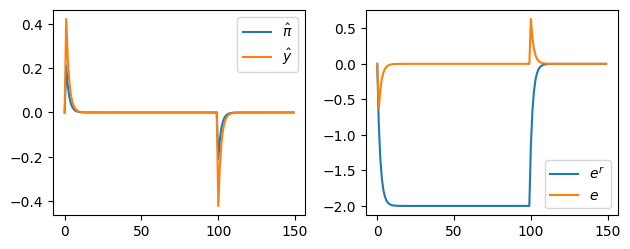

In [4]:
periods = 150 # Choose amount of periods to plot
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,periods,1),model.path.pihat[:periods],label=r'$\hat{\pi}$')
ax.plot(range(0,periods,1),model.path.yhat[:periods],label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,periods,1),model.path.er[:periods],label=r'$e^r$')
ax.plot(range(0,periods,1),model.path.e[:periods],label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()


To compare it to a situation in which the central bank does not target output, we can set b=0

In [5]:
model.par.b = 0
model.shocks(1,100,1,z=True)
model.solve()

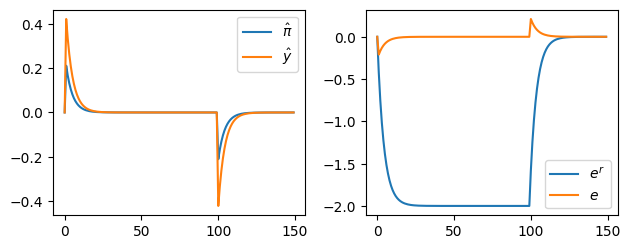

In [6]:
periods = 150 # Choose amount of periods to plot
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,periods,1),model.path.pihat[:periods],label=r'$\hat{\pi}$')
ax.plot(range(0,periods,1),model.path.yhat[:periods],label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,periods,1),model.path.er[:periods],label=r'$e^r$')
ax.plot(range(0,periods,1),model.path.e[:periods],label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

The nominal exhangerate changes less, while the speed of convergence of the variables generally becomes slower. This is more so the case for the output gap than the inflation gap, since the CB is only targeting inflation. Now we turn to a negative supply shock for a similar timeframe.

In [7]:
# Reset shock variables and b
model = ASAD_class()
model.par.b = 0.5 
model.shocks(1,100,1,s=True)
model.solve()

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


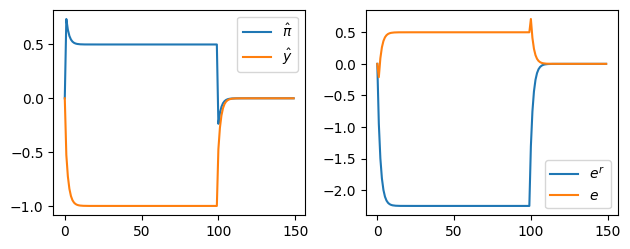

In [8]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,periods,1),model.path.pihat[:periods],label=r'$\hat{\pi}$')
ax.plot(range(0,periods,1),model.path.yhat[:periods],label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,periods,1),model.path.er[:periods],label=r'$e^r$')
ax.plot(range(0,periods,1),model.path.e[:periods],label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

Since the CB mainly is able to affect the demand side of the economy, the output gap remains negative for the duration of the supply shock. The central bank lowers the interest rate as a response, to limit rising inflation. To see the importance of the size of the b parameter (how much the CB targets output), we run the shock again with b=0.9

In [9]:
# Reset shock variables and b
model = ASAD_class()
model.par.b = 0.9 
model.shocks(1,100,1,s=True)
model.solve()

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


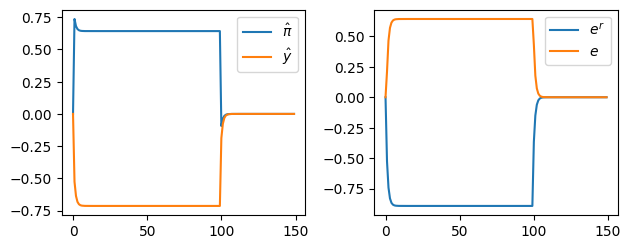

In [10]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,periods,1),model.path.pihat[:periods],label=r'$\hat{\pi}$')
ax.plot(range(0,periods,1),model.path.yhat[:periods],label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,periods,1),model.path.er[:periods],label=r'$e^r$')
ax.plot(range(0,periods,1),model.path.e[:periods],label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

Output gap is still negative, but less so than for b=0.5. On the other hand, the inflation gap stays at a higher level for the duration of the shock.

(explain intuition)

## 2. Stochastic Shocks

In [11]:
# Reset shock variables
model = ASAD_class()
model.par.b = 0.5 
# Load stochastic shocks and solve model
model.stochastic_shocks(0,1,z=True)
model.solve()

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


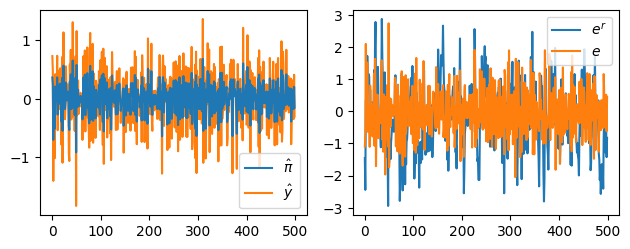

In [12]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$', zorder=10)
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

In [13]:
# Reset shock variables
model = ASAD_class()
# Load stochastic shocks and solve model
model.stochastic_shocks(0,1,s=True)
model.solve()

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


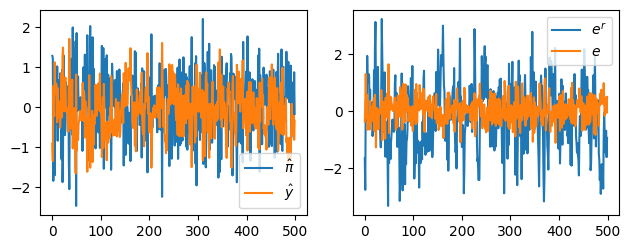

In [14]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

## 3. Persistent, stochastic shocks (AR)

### Demand shocks as an AR-process

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


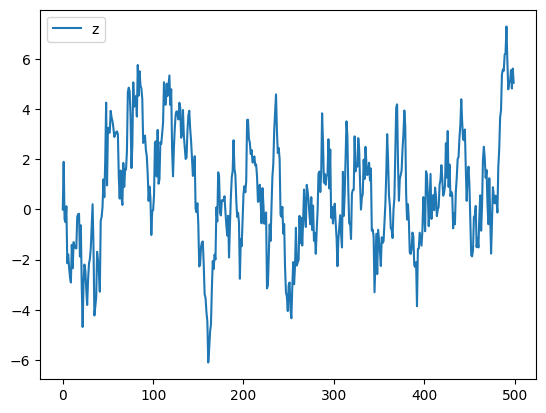

In [15]:
# Reset shock variables
model = ASAD_class()
# Load stochastic AR shocks and plot them
model.AR_shocks(rho=0.9,sd=1,z=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.z,label=r'z')
ax.legend(frameon=True)

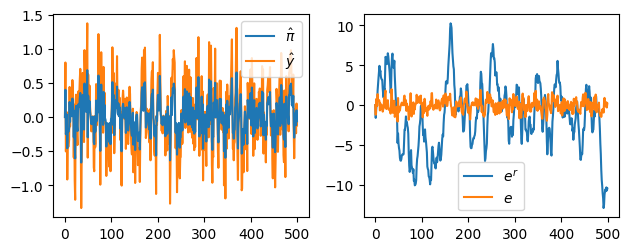

In [16]:
model.solve()

fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$', zorder=10)
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')

ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

### Supply shocks as an AR-process

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


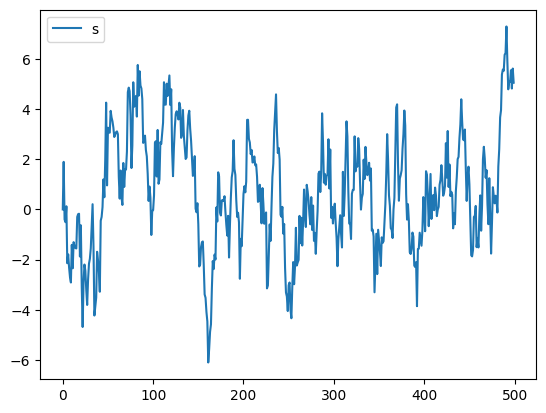

In [17]:
# Reset shock variables
model = ASAD_class()
# Supply AR shock
model.AR_shocks(rho=0.9,sd=1,s=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.s,label=r's')
ax.legend(frameon=True)

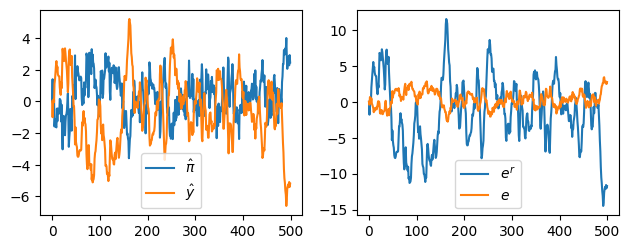

In [18]:
model.solve()

fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

## 4. The super, social planner, living in an AR-world

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


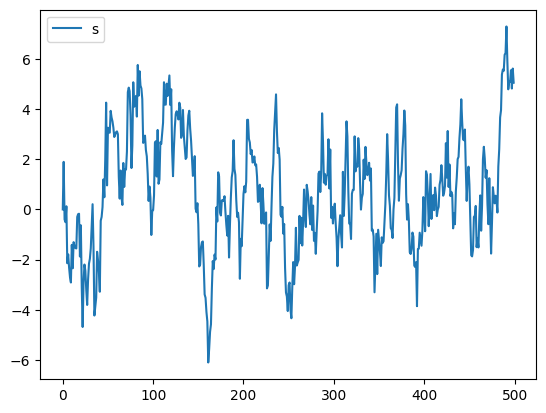

In [19]:
# Reset shock variables
model = ASAD_class()
# AR supply shock
model.AR_shocks(rho=0.9,sd=1,s=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.s,label=r's')
ax.legend(frameon=True)

In [20]:
sl = np.zeros((20,20))
possible_h = np.linspace(0,2,num=20)
possible_b = np.linspace(0,2,num=20)

def slhb(x):
    h, b = x
    model.par.h = h
    model.par.b = b
    model.solve()
    return model.compute_social_loss()

In [21]:
sl_best = np.inf
h_best = np.nan
b_best = np.nan

# Create a matrix to store the results
sl = np.zeros((len(possible_h), len(possible_b)))

for i, h in enumerate(possible_h):
    for j, b in enumerate(possible_b):
        x = np.array([h, b])
        sl_value = slhb(x)  # Compute social loss for (h, b)
        sl[i, j] = sl_value
        
        if sl_value < sl_best:
            sl_best = sl_value
            h_best = h
            b_best = b

print(h_best, b_best, sl_best)

0.3157894736842105 1.5789473684210527 2314.5598402711526


In [22]:
# Alternative using a solver
x_init = np.array([0,0])
social_loss = scipy.optimize.minimize(slhb,x0=x_init, method='nelder-mead')

In [23]:
# Access the optimized parameters
optimized_parameters = social_loss.x
print("Optimized parameters (h, b):", optimized_parameters)

# Access the minimum value of the objective function
min_loss = social_loss.fun
print("Minimum value of the objective function:", min_loss)

Optimized parameters (h, b): [0.37342521 1.69117551]
Minimum value of the objective function: 2314.5271631039413


The cell below calculates social loss for a larger grid (50x50), so it takes a while to load. Makes it easier to see the slopes of the surfaceplot

In [24]:
# Generate values for h and b
h_values = np.linspace(0, 2, num=50)
b_values = np.linspace(0, 2, num=50)

# Create a grid of h and b values
H, B = np.meshgrid(h_values, b_values)

# Compute the social loss for each combination of h and b
social_loss_values = np.zeros_like(H)
for i in range(len(h_values)):
    for j in range(len(b_values)):
        model.par.h = H[i, j]
        model.par.b = B[i, j]
        model.solve()
        social_loss_values[i, j] = model.compute_social_loss()



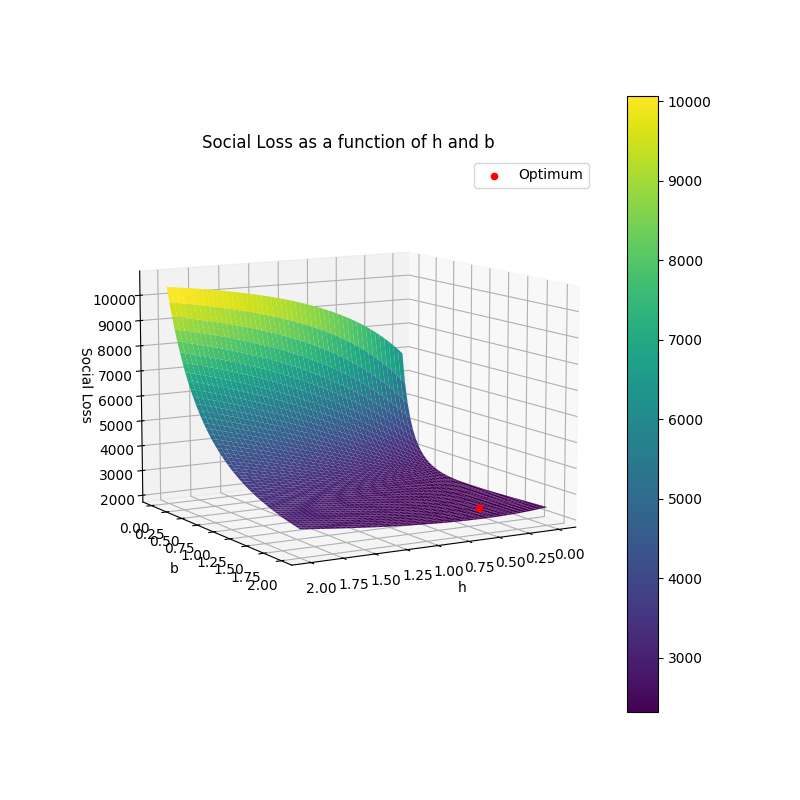

In [25]:
# Plot the surface
%matplotlib ipympl
fig = plt.figure(figsize=(8, 8)) 
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)
surf = ax.plot_surface(H, B, social_loss_values, cmap='viridis')
# Plot optimum point
ax.scatter(optimized_parameters[0], optimized_parameters[1], min_loss, color='red', label='Optimum', s=20)
# Set labels and title
ax.set_xlabel('h')
ax.set_ylabel('b')
ax.set_zlabel('Social Loss')
ax.set_title('Social Loss as a function of h and b')

fig.colorbar(surf)
ax.legend()

ax.view_init(elev=10, azim=60)
plt.show()